# **Image Processor Without Libraries**

1. import necessary libraries

In [72]:
import numpy as np
import pathlib 
from PIL import Image

2. Determine the path of the image and load the image using pillow

In [73]:
path = pathlib.Path.cwd() / "images.jpg"
image = Image.open(path)

3. convert the image into numpy array
* the .shape() tell the (height , width , colors(rgb))

In [74]:
image_array = np.array(image)
print(f"Array shape : {image_array.shape}")
print(f"Array Dimension : {image_array.ndim}")


Array shape : (455, 674, 3)
Array Dimension : 3


## change Brightness of the image

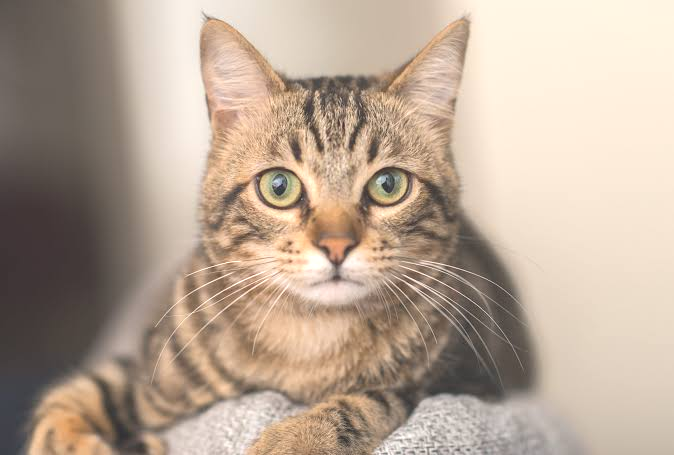

In [ ]:
def change_brightness(b_level):
    transform_image = np.clip(image_array.astype(np.int16) + b_level , 0 , 255).astype(np.uint8)
    return Image.fromarray(transform_image)

change_brightness(50)


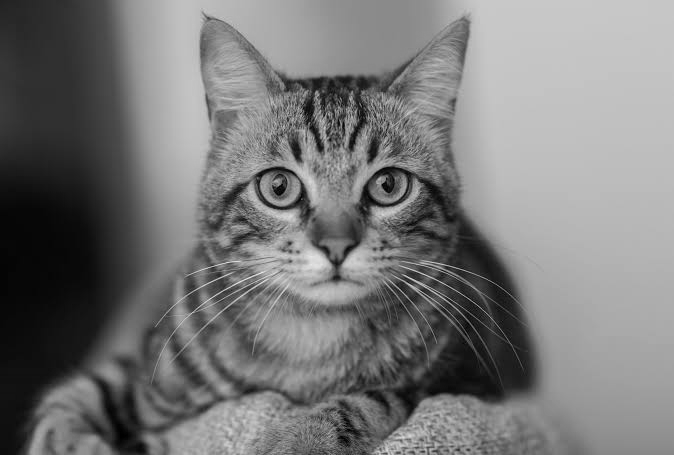

In [82]:
def grayscale():
   
    R = image_array[:, :, 0]
    G = image_array[:, :, 1]
    B = image_array[:, :, 2]

    grayscale_image = (R * 0.2989) + (G * 0.5870) + (B * 0.1140)

    grayscale_image = np.clip(grayscale_image, 0, 255).astype(np.uint8)

    return Image.fromarray(grayscale_image)

grayscale()


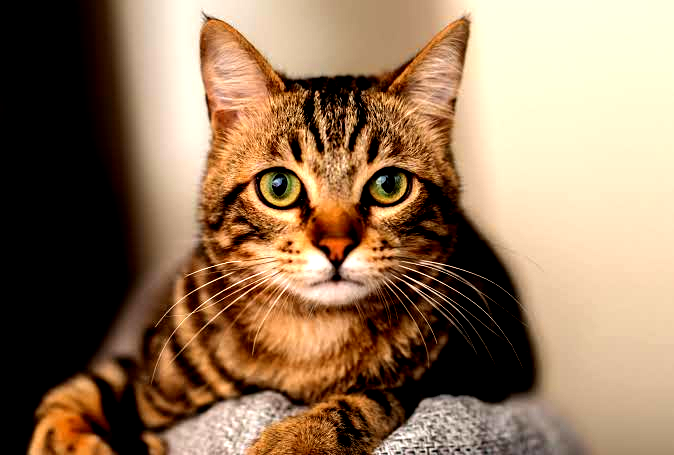

In [101]:

def contrast(factor):
    x = image_array.astype(np.int16)
    array = ( 127 + (x - 127) * factor )
    array =  np.clip(array , 0 ,255).astype(np.uint8)
    return Image.fromarray(array)
contrast(2.0)

In [ ]:


def blur(kernel_size):
    output = np.zeros_like(image_array)
    pad = kernel_size // 2
    h, w, c = image_array.shape
    
    for i in range(pad, h - pad):
        for j in range(pad, w - pad):
            
            patch = image_array[i - pad : i + pad + 1, j - pad : j + pad + 1]
            
            output[i, j] = np.mean(patch, axis=(0,1))
            
    return Image.fromarray(output)

blurred_image = blur(5) 
